In [ ]:
import pandas as pd #helps with working with tables and datasets

In [ ]:
import matplotlib.pyplot as plt #helps me make charts


In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv') #loading the dataset from the URL

In [ ]:
df.head() #looking at the first 5 rows

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df.shape #checking how many rows and columns are in the dataset

(101766, 50)

In [ ]:
df.info() #viewing the columns and dta types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
df = df.replace ('?',pd.NA) #cleaning missing value

In [ ]:
df.isnull().sum() #checking for missing values

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
df['gender'].value_counts() #checking how many patients are in each gender group

,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3


In [ ]:
gender_df = df[df['gender'].isin(['Male', 'Female'])] #create a new dataframe that only includes Male and Female patients and remove Unknown/Invalid

In [ ]:
gender_df['gender'].value_counts() #provides a count and confirms how many males and females are in the dataset

,count
gender,
Female,54708
Male,47055


In [ ]:
gender_df.groupby('gender')['time_in_hospital'].describe() #descriptive statistic for time in hospital

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Female,54708.0,4.478797,2.980388,1.0,2.0,4.0,6.0,14.0
Male,47055.0,4.299777,2.987703,1.0,2.0,3.0,6.0,14.0


In [ ]:
average_stay=gender_df.groupby('gender')['time_in_hospital'].mean() #calculate the average number of days spent in the hospital for each gender group
average_stay #display the average hospital stay for males and females

,time_in_hospital
gender,
Female,4.478797
Male,4.299777


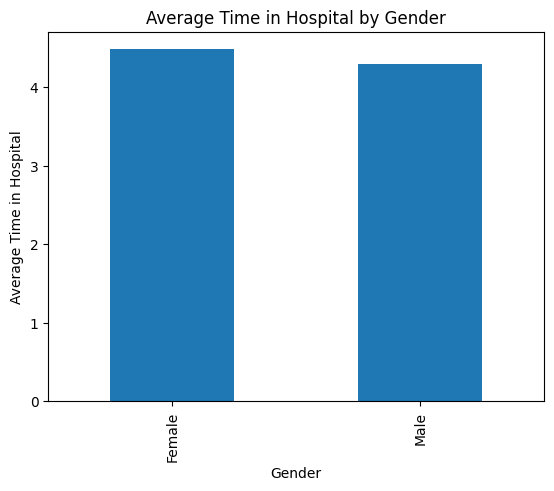

In [ ]:
average_stay.plot(kind='bar') #create a bar chart from the avergages. Each bar represents a gender group

plt.title('Average Time in Hospital by Gender') #add a title to explain what the chart shows
plt.xlabel('Gender') #label the x-axis (categories)
plt.ylabel('Average Time in Hospital') #label the y-axis (values)
plt.show() #display the chart


In [ ]:
readmit_avg = gender_df.groupby('readmitted')['time_in_hospital'].mean() #grouping the data by readmission status (<30, >30, NO), then calculating the average number of days in the hosptial for each group
readmit_avg #display the average hosptial stay for each readmission

,time_in_hospital
readmitted,
<30,4.768249
>30,4.495541
NO,4.254480


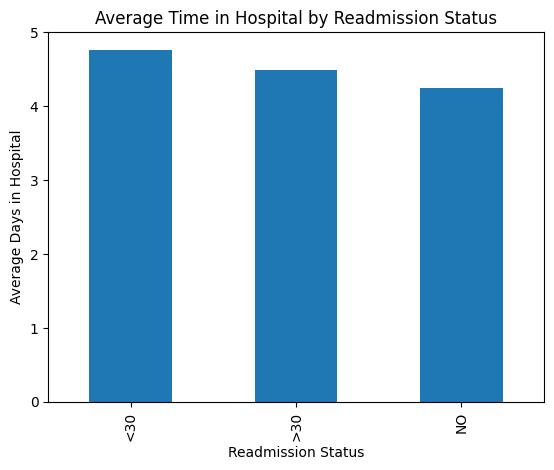

In [ ]:
readmit_avg.plot(kind='bar') #create a bar chart from the averages. Each bar represents a readmission group
plt.title('Average Time in Hospital by Readmission Status') #adds a title to explain what the chart shows
plt.xlabel('Readmission Status') #labeling the x-axis (categories)
plt.ylabel('Average Days in Hospital') #labeling the y-axis (values)
plt.show() #displays the chart

This analysis compare hosptial stay duration by gender and readmission status. While females had a slightly higher average stay than males, patients who were readmitted, especialy within 30 days had longer stays overall.